In [19]:
import os
import torch
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
from optical.utils.test_utils import LoadDataset
from optical.surface import WaterSurface
from gsplat import rasterization

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
Dataset = LoadDataset()
Dataset.set_iamge(20)

# means, scales, quats, opacities, colors = Dataset.get_model_param()
pixels_wo, pixels_w, camtoworld, worldtocam, cam_center, K, height, width, image_id = Dataset.get_camera_param()

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.
Loading 3D point cloud from: /home/taiki/dataset/river2/refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/refraction.


In [21]:
# grid parameters
grid_step = 1.0    # spacing between grid lines
points_distance = 0.01  # spacing between points along each grid line

x_min, x_max = -20.0, 20.0
z_min, z_max = -20.0,  0.0

# build the 1D coords of where your grid‐lines sit
xs = torch.arange(x_min, x_max + grid_step, grid_step, device=device)
zs = torch.arange(z_min, z_max + grid_step, grid_step, device=device)

pts_list = []

# sample points along each "vertical" (constant‐x) line
for x in xs:
    z_line = torch.arange(z_min, z_max + 1e-6, points_distance, device=device)
    pts_list.append(torch.stack([
        x.expand_as(z_line),
        torch.zeros_like(z_line),
        z_line
    ], dim=1))

# sample points along each "horizontal" (constant‐z) line
for z in zs:
    x_line = torch.arange(x_min, x_max + 1e-6, points_distance, device=device)
    pts_list.append(torch.stack([
        x_line,
        torch.zeros_like(x_line),
        z.expand_as(x_line)
    ], dim=1))

# concatenate into one (N,3) cloud
pts = torch.cat(pts_list, dim=0)
pts.shape  # e.g. (num_lines * num_samples_per_line, 3)

torch.Size([166062, 3])

cam_center torch.Size([3])


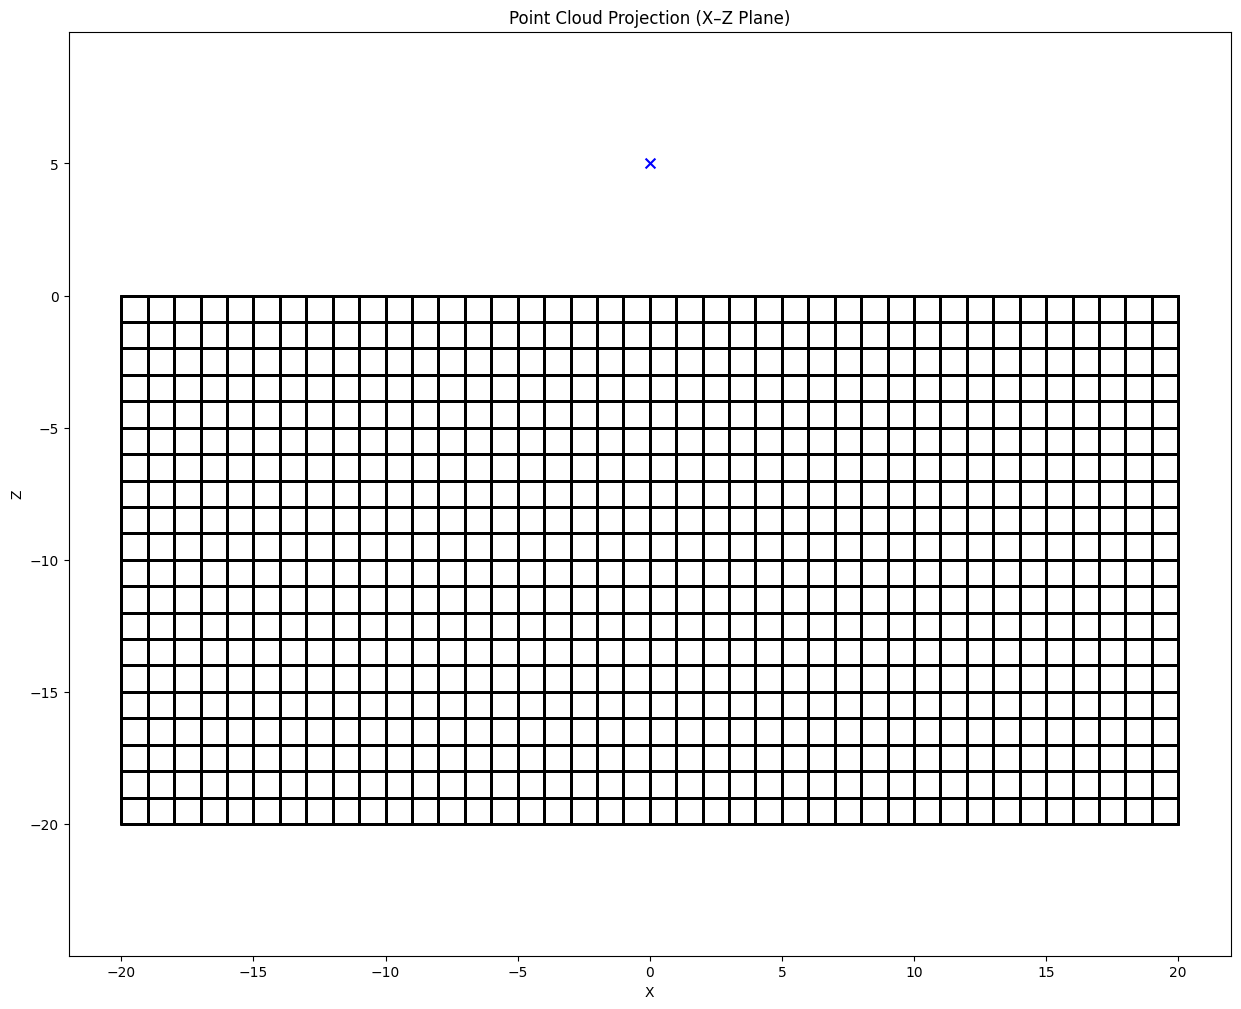

In [39]:
# Scatter plot of the point‐cloud on the X–Z plane
cam_x = 0
# cam_z = 10
cam_z = 5

cam_center = torch.tensor([cam_x, 0, cam_z], device=device)
print("cam_center", cam_center.shape)

camtoworld = torch.eye(4, device=device).unsqueeze(0).expand(1,4,4)
camtoworld[:, :3, 3] = cam_center.unsqueeze(0)
worldtocam = camtoworld.inverse()

x = pts[:, 0].cpu().numpy()
z = pts[:, 2].cpu().numpy()

plt.figure()
plt.scatter(x, z, s=1, c='black')
plt.scatter(cam_x, cam_z, s=50, c='blue', marker='x', label='Camera')
plt.xlabel('X')
plt.ylabel('Z')
plt.xlim(x_min, x_max)
plt.ylim(z_min, z_max)
plt.title('Point Cloud Projection (X–Z Plane)')
plt.axis('equal')
plt.show()

In [40]:
# Create Gaussian model
scale_abs   = torch.tensor(5.0,   device=device)
opacity_abs = torch.tensor(0.99,  device=device)

scale_param   = torch.log(scale_abs)
opacity_param = torch.logit(opacity_abs)

# extend Gaussians to all points
num_gauss = pts.shape[0]
means     = pts                                      # (N,3)
scales    = torch.cat([
               scale_param.unsqueeze(0).expand(num_gauss,2),
               torch.zeros(num_gauss,1,device=device)
           ], dim=1)                                  # (N,3)
quats     = torch.tensor([1.,0.,0.,0.],device=device).repeat(num_gauss,1)  # (N,4)
opacities = opacity_param.expand(num_gauss)            # (N,)
colors    = torch.ones(num_gauss,3,device=device).unsqueeze(1)    # (N,1,3)


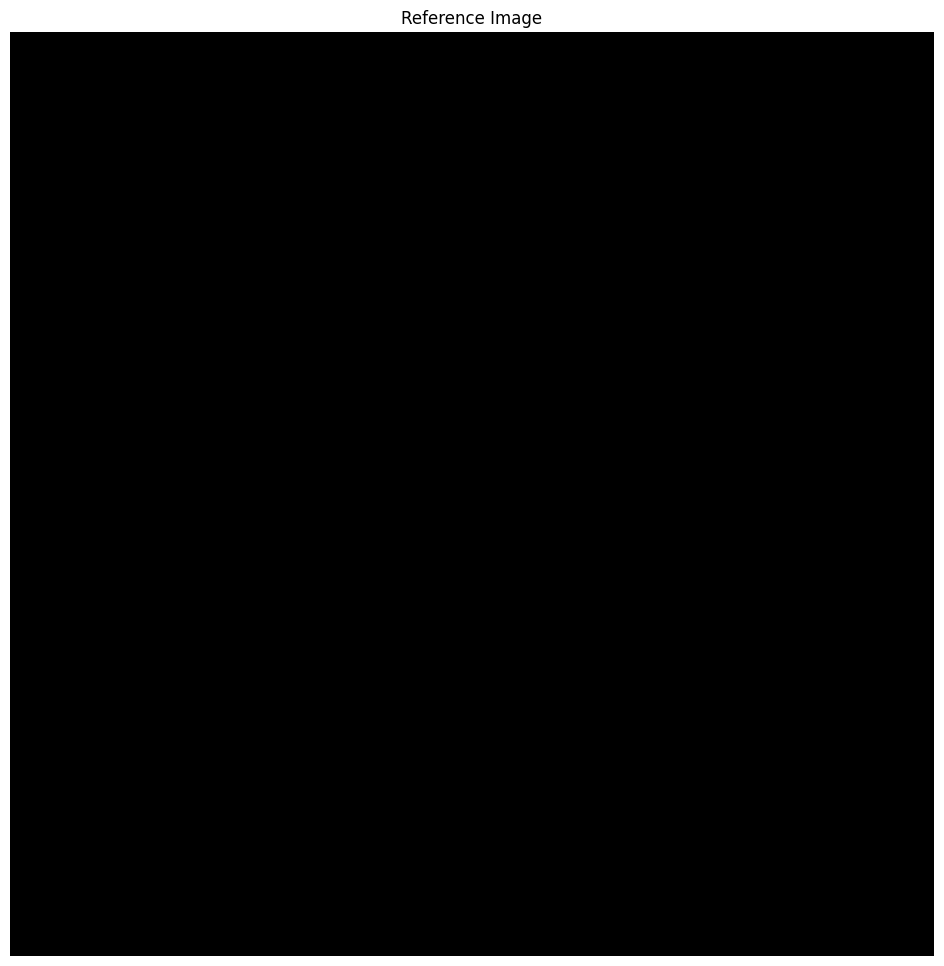

In [41]:
# Render
rgb_wo_ref, _, _ = rasterization(
    pts,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,  # Notice! Render world to cam matrix 
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_ref = rgb_wo_ref.squeeze().cpu().detach().numpy()

# Show the reference image
plt.imshow(rgb_wo_ref)
plt.axis('off')
plt.title('Reference Image')
plt.show()

In [42]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
newton_iters = 10
newton_tol = 1e-6

WS = WaterSurface(
    means=pts,
    quats=quats,
    scales=scales,
    opacities=opacities,
    cam_center=cam_center,
    n=n,
    plane=plane,
    flag_solve_quartic_by_newton=True,
)

trandformed_pts, trandformed_quats = WS.transform_to_appearance()

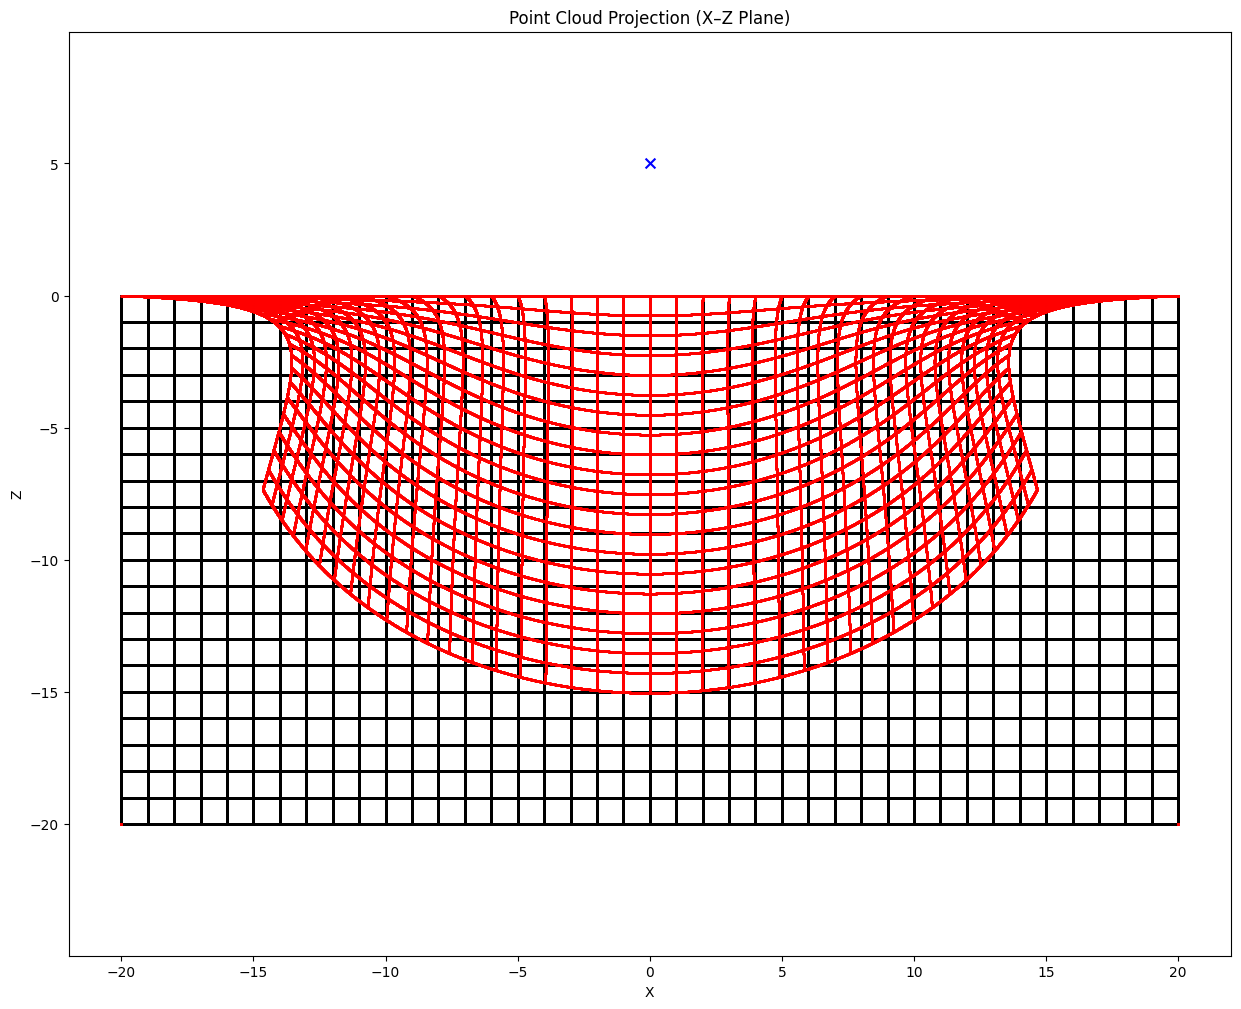

In [43]:
# Scatter plot of the point‐cloud on the X–Z plane
t_x = trandformed_pts[:, 0].cpu().numpy().clip(x_min, x_max)
t_z = trandformed_pts[:, 2].cpu().numpy().clip(z_min, z_max)

plt.figure()
plt.scatter(x, z, s=1, c='black')
plt.scatter(cam_x, cam_z, s=50, c='blue', marker='x', label='Camera')
plt.scatter(t_x, t_z, s=1, c='red', label='Transformed Points')
plt.xlabel('X')
plt.ylabel('Z')
plt.xlim(x_min, x_max)
plt.ylim(z_min, z_max)
plt.title('Point Cloud Projection (X–Z Plane)')
plt.axis('equal')
plt.show()

In [51]:
# grid parameters
grid_step = 0.5    # spacing between grid lines

x_min, x_max = -20.0, 20.0
z_min, z_max = -20.0,  0.0

xs = torch.arange(x_min, x_max+ grid_step, grid_step, device=device)
zs = torch.arange(z_min, z_max + grid_step, grid_step, device=device)

pts_list = []
for x in xs:
    for z in zs:
        pts_list.append(torch.tensor([x, 0.0, z], device=device))
        
grid_pts = torch.stack(pts_list, dim=0)


# Create Gaussian model
scale_abs   = torch.tensor(5.0,   device=device)
opacity_abs = torch.tensor(0.99,  device=device)

scale_param   = torch.log(scale_abs)
opacity_param = torch.logit(opacity_abs)

# extend Gaussians to all points
num_gauss = grid_pts.shape[0]
grid_means     = pts                                      # (N,3)
grid_scales    = torch.cat([
               scale_param.unsqueeze(0).expand(num_gauss,2),
               torch.zeros(num_gauss,1,device=device)
           ], dim=1)                                  # (N,3)
grid_quats     = torch.tensor([1.,0.,0.,0.],device=device).repeat(num_gauss,1)  # (N,4)
grid_opacities = opacity_param.expand(num_gauss)            # (N,)
grid_colors    = torch.ones(num_gauss,3,device=device).unsqueeze(1)    # (N,1,3)

grid_WS = WaterSurface(
    means=grid_pts,
    quats=grid_quats,
    scales=grid_scales,
    opacities=grid_opacities,
    cam_center=cam_center,
    n=n,
    plane=plane,
    flag_solve_quartic_by_newton=True,
    newton_iters=newton_iters,
    newton_tol=newton_tol,
)

grid_t_pts, grid_t_quats = grid_WS.transform_to_appearance()


num_grid_z = int((z_max - z_min) // grid_step + 1)


def compute_deformation_area(pts, t_pts, num_grid_z):

    # original_grid_size = math.abs((xs[1] - xs[0]) * (zs[1] - zs[0]))
    original_grid_size = grid_step * grid_step 
    
    num_points = pts.shape[0]
    deformation_rates = torch.zeros(num_points, device=device)
    # print("num_points", num_points)
    # print("deformation_rates", deformation_rates.shape)
    
    for i in range(num_points):
        
        neigbors = []
        # upper neighbor exists
        if (i + 1) % num_grid_z != 0:
            neigbors.append(i+1)
        # right neighbor exists
        if i + num_grid_z < num_points:
            neigbors.append(i + num_grid_z)
        # right upper neighbor exists (in case, ↙ corner of right upper)
        if i != num_points - num_grid_z - 2:
            neigbors.append(i + num_grid_z + 1)
            
        if len(neigbors) != 3:
            continue
        
        # print("exists")
        # calculate deformation area
        v1 = (t_pts[neigbors[0]] - t_pts[i])[[0,2]]
        v2 = (t_pts[neigbors[1]] - t_pts[i])[[0,2]]
        # deformation_grid_size = torch.abs(torch.dot(v1, v2))
        # 上 左の隣接の座標の外戚、なす角度のみらら空間の圧縮率がめらるるる
        deformation_grid_size = torch.abs(v1[0] * v2[1] - v1[1] * v2[0])  
        
        deformation_rate = deformation_grid_size / original_grid_size
        # deformation_rate = original_grid_size / deformation_grid_size

        deformation_rates[i] = deformation_rate

    return torch.tensor(deformation_rates, device=device)

deformation_rates = compute_deformation_area(grid_pts, grid_t_pts, num_grid_z)  
deformation_rates

/tmp/ipykernel_1219337/802993770.py:94: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(deformation_rates, device=device)


tensor([0.3724, 0.3614, 0.3502,  ..., 0.0000, 0.0000, 0.0000], device='cuda:0')

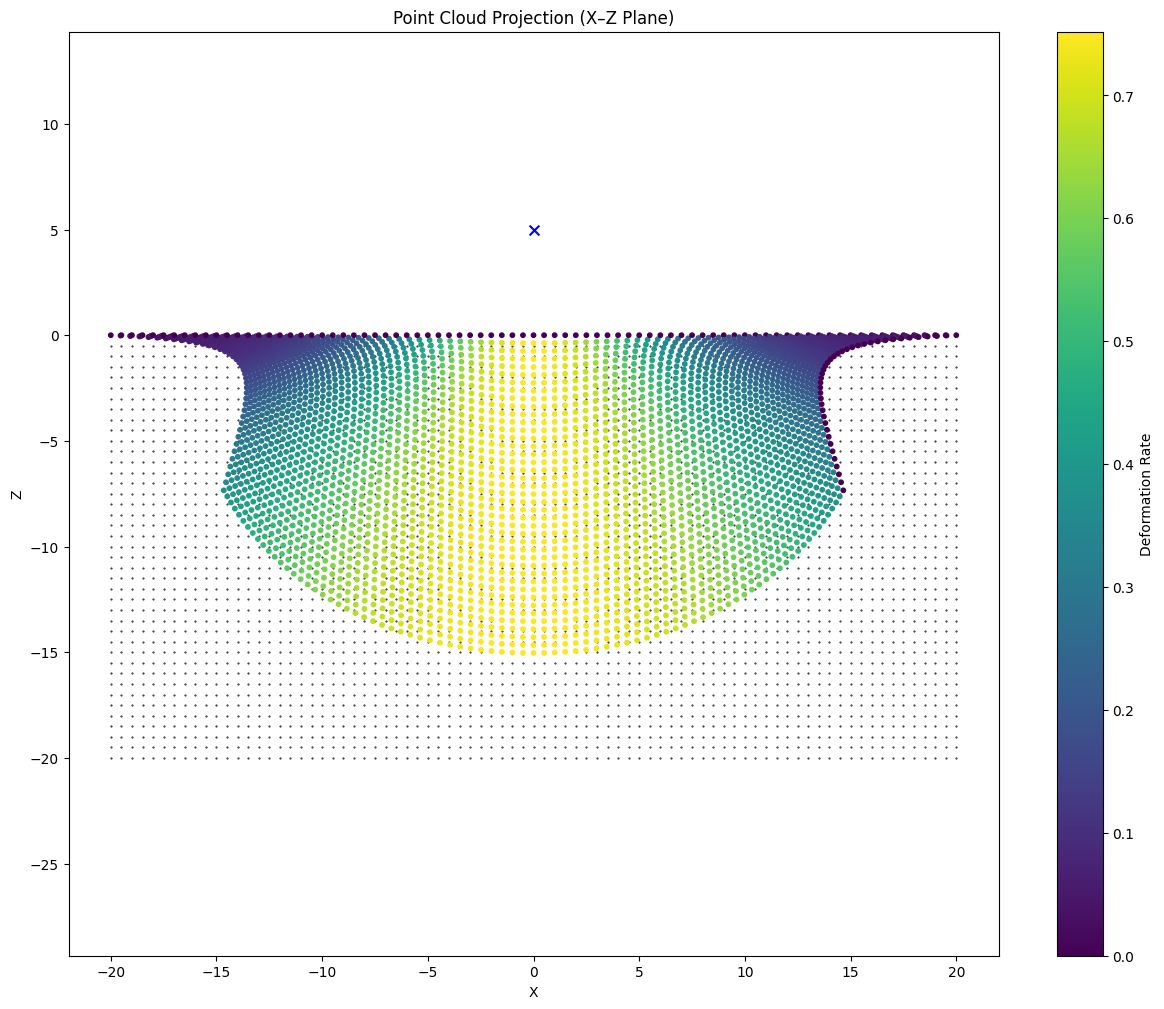

grid_pts shape torch.Size([3321, 3])
grid_t_pts shape torch.Size([3321, 3])
deformation_rates shape torch.Size([3321])


In [52]:
# Scatter plot of the point‐cloud on the X–Z plane
grid_x = grid_pts[:, 0].cpu().numpy().clip(x_min, x_max)
grid_z = grid_pts[:, 2].cpu().numpy().clip(z_min, z_max)

grid_t_x = grid_t_pts[:, 0].cpu().numpy().clip(x_min, x_max)
grid_t_z = grid_t_pts[:, 2].cpu().numpy().clip(z_min, z_max)


plt.figure()
plt.scatter(grid_x, grid_z, s=0.2, c='black')
plt.scatter(cam_x, cam_z, s=50, c='blue', marker='x', label='Camera')
plt.scatter(grid_t_x, grid_t_z, s=10, c=deformation_rates.cpu().numpy(), cmap='viridis', label='Transformed Points')
plt.colorbar(label='Deformation Rate')
plt.xlabel('X')
plt.ylabel('Z')
plt.xlim(x_min, x_max)
plt.ylim(z_min, z_max)
plt.title('Point Cloud Projection (X–Z Plane)')
plt.axis('equal')
plt.show()

print("grid_pts shape", grid_pts.shape)
print("grid_t_pts shape", grid_t_pts.shape)
print("deformation_rates shape", deformation_rates.shape)